In [5]:
import pandas as pd
from pathlib import Path

# adjust path if needed
parquet_path = Path("data/derivatives/nflx/segments_nflx_v2.parquet")
segments = pd.read_parquet(parquet_path)

target_columns = [
    "target__revenue",
    "target__engagement",
    "target__acquisition",
    "target__live_event",
    "target__subscriber",
    "target__guidance",
    "target__competition",
    "target__profitable",
    "target__gaming",
    "target__ad_supported",
    "target__price_change",
    "target__partnership",
    "target__hollywood",
    "target__churn",
]


In [6]:
# event-level label = did he say it at least once in that conference?
event_flags = (
    segments.groupby("event_id")[target_columns]
    .max()
    .reset_index()
)

# compute base rate across events for each target, sorted
base_rates = (
    event_flags[target_columns]
    .mean()
    .sort_values(ascending=False)
    .rename("historical_prob")
    .to_frame()
)
base_rates.index = base_rates.index.str.replace("target__", "", regex=False)
base_rates


,historical_prob
revenue,1.000000
engagement,1.000000
subscriber,0.888889
guidance,0.777778
churn,0.777778
competition,0.777778
gaming,0.666667
acquisition,0.666667
live_event,0.555556
price_change,0.555556


In [7]:
target = "target__hollywood"  # change as needed

# per-event indicator + optional dates if present
cols = ["event_id", target]
if "event_date" in segments.columns:
    cols.append("event_date")

ev = (
    segments[cols]
    .groupby("event_id", as_index=False)
    .max()
    .sort_values(cols[-1] if "event_date" in cols else "event_id")
    .rename(columns={target: "mentioned"})
)

ev

,event_id,mentioned,event_date
0,1Q21_EARNINGS,True,2021-03-31
5,2Q21_EARNINGS,False,2021-06-30
10,3Q21_EARNINGS,False,2021-09-30
14,4Q21_EARNINGS,False,2021-12-31
1,1Q22_EARNINGS,False,2022-03-31
6,2Q22_EARNINGS,False,2022-06-30
11,3Q22_EARNINGS,False,2022-09-30
15,4Q22_EARNINGS,False,2022-12-31
2,1Q23_EARNINGS,False,2023-03-31
7,2Q23_EARNINGS,False,2023-06-30


In [8]:
import numpy as np

def wilson_interval(k, n, z=1.96):  # 95% CI by default
    if n == 0:
        return (0.0, 1.0)
    phat = k / n
    denom = 1 + z**2 / n
    centre = phat + z**2 / (2*n)
    adj = z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n)
    lo = (centre - adj) / denom
    hi = (centre + adj) / denom
    return float(max(0, lo)), float(min(1, hi))

# build CI table for all targets
event_counts = (segments.groupby("event_id")[target_columns].max())
n_events = len(event_counts)

rows = []
for tc in target_columns:
    k = int(event_counts[tc].sum())  # number of events where mentioned ≥1x
    lo, hi = wilson_interval(k, n_events)
    rows.append({"target": tc.replace("target__", ""), "k": k, "n": n_events,
                 "prob": k/n_events, "ci_lo": lo, "ci_hi": hi})

ci_df = pd.DataFrame(rows).sort_values("prob", ascending=False).reset_index(drop=True)
ci_df

,target,k,n,prob,ci_lo,ci_hi
0,revenue,18,18,1.000000,0.824115,1.000000
1,engagement,18,18,1.000000,0.824115,1.000000
2,subscriber,16,18,0.888889,0.671998,0.968981
3,guidance,14,18,0.777778,0.547850,0.909992
4,churn,14,18,0.777778,0.547850,0.909992
5,competition,14,18,0.777778,0.547850,0.909992
6,gaming,12,18,0.666667,0.437491,0.837214
7,acquisition,12,18,0.666667,0.437491,0.837214
8,live_event,10,18,0.555556,0.337161,0.754408
9,price_change,10,18,0.555556,0.337161,0.754408


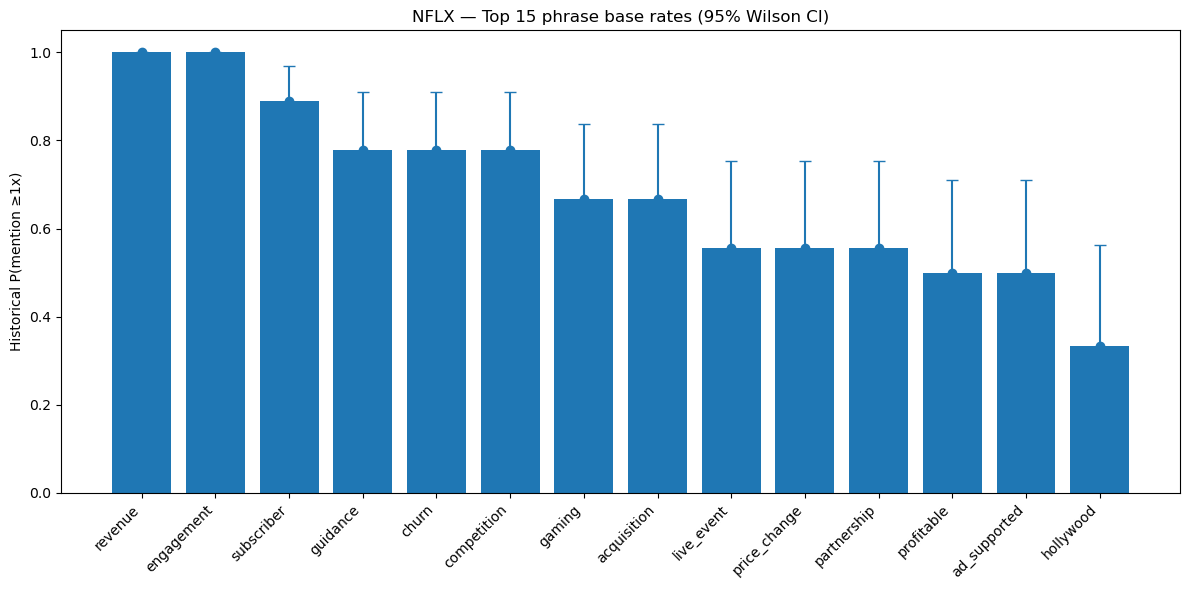

In [9]:
import matplotlib.pyplot as plt

top_n = 15
top = ci_df.head(top_n).copy()

x = np.arange(len(top))
y = top["prob"].values
yerr = np.vstack([y - top["ci_lo"].values, top["ci_hi"].values - y])

plt.figure(figsize=(12, 6))
plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
plt.xticks(x, top["target"].tolist(), rotation=45, ha="right")
plt.ylabel("Historical P(mention ≥1x)")
plt.title(f"NFLX — Top {top_n} phrase base rates (95% Wilson CI)")
plt.tight_layout()
plt.show()


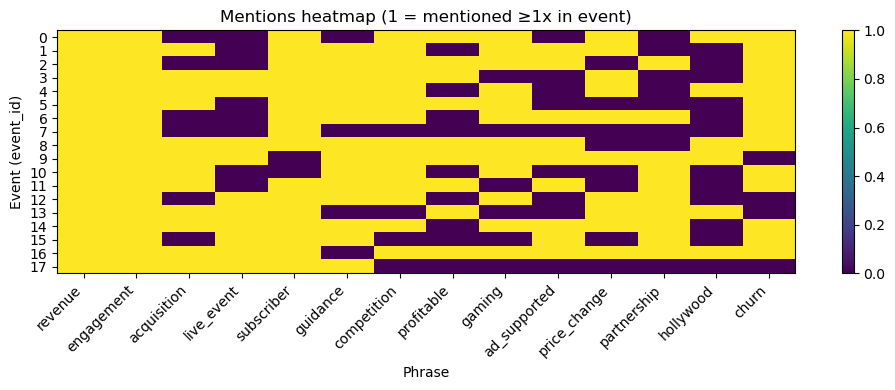

In [10]:
# subset_targets = [
#     "target__credit", "target__recession",
#     "target__inflation" if "target__inflation" in event_flags.columns else "target__growth",
#     "target__balance_sheet", "target__yield_curve", "target__bitcoin", "target__gold"
# ]
subset_targets = [t for t in target_columns if t in event_flags.columns]

if "event_date" in segments.columns:
    ev_dates = segments[["event_id", "event_date"]].drop_duplicates().set_index("event_id")
    ev_flags = event_flags.join(ev_dates, how="left").sort_values("event_date")
else:
    ev_flags = event_flags.copy()

if subset_targets:
    mat = ev_flags[subset_targets].astype(int).values
    plt.figure(figsize=(10, max(4, mat.shape[0]*0.2)))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(ev_flags.shape[0]), ev_flags.index.tolist())
    plt.xticks(np.arange(len(subset_targets)), [t.replace("target__", "") for t in subset_targets], rotation=45, ha="right")
    plt.xlabel("Phrase")
    plt.ylabel("Event (event_id)")
    plt.title("Mentions heatmap (1 = mentioned ≥1x in event)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


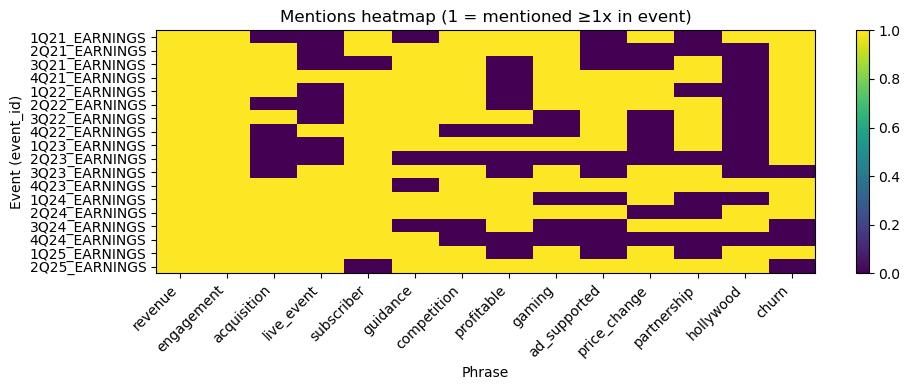

In [11]:
subset_targets = [t for t in target_columns if t in event_flags.columns]

# 1) Build canonical chronological order from segments
events = (
    segments[["event_id", "event_date"]]
    .drop_duplicates()
    .assign(event_date=pd.to_datetime(segments["event_date"]))
    .sort_values("event_date")
)

row_order = events["event_id"].tolist()  # e.g., ["1Q23_EARNINGS","2Q23_EARNINGS",...]

# 2) Make sure ev_flags is indexed by event_id, then reindex to chronological order
ev_flags = event_flags.copy()
if ev_flags.index.name != "event_id":
    ev_flags = ev_flags.reset_index().rename(columns={ev_flags.index.name: "event_id"}).set_index("event_id")

ev_flags = ev_flags.reindex(row_order)

# (optional) keep event_date for reference/debug, not used for ordering anymore
ev_flags = ev_flags.join(events.set_index("event_id")["event_date"], how="left")

# 3) Plot
if subset_targets:
    mat = ev_flags[subset_targets].astype(int).values
    plt.figure(figsize=(10, max(4, mat.shape[0]*0.2)))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(ev_flags.shape[0]), ev_flags.index.tolist())  # now chronological
    plt.xticks(
        np.arange(len(subset_targets)),
        [t.replace("target__", "") for t in subset_targets],
        rotation=45, ha="right"
    )
    plt.xlabel("Phrase")
    plt.ylabel("Event (event_id)")
    plt.title("Mentions heatmap (1 = mentioned ≥1x in event)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


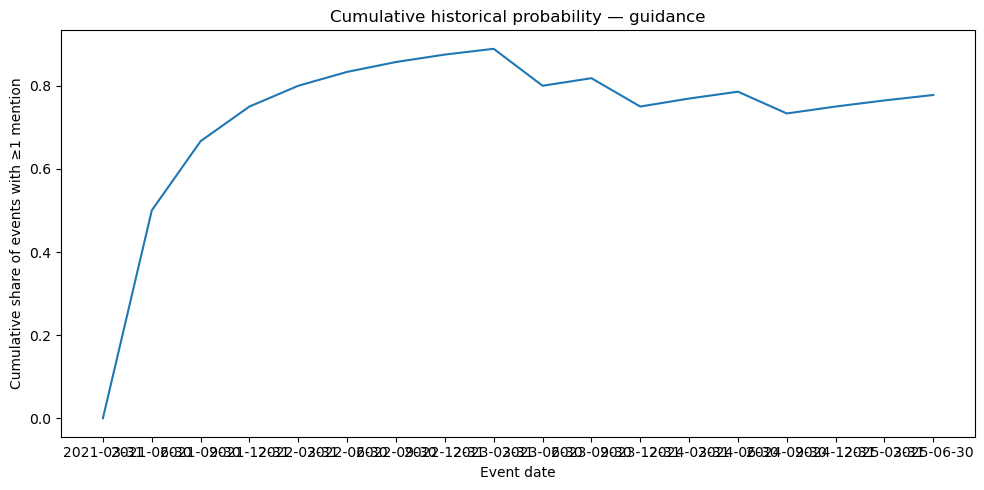

In [12]:
target = "target__guidance"  # change freely

if "event_date" in segments.columns:
    ev = segments[["event_id","event_date",target]].groupby(["event_id","event_date"], as_index=False).max().sort_values("event_date")
    x = ev["event_date"]
else:
    ev = segments[["event_id",target]].groupby("event_id", as_index=False).max().sort_values("event_id")
    ev["idx"] = np.arange(1, len(ev)+1)
    x = ev["idx"]

ev["cum_mentioned"] = ev[target].cumsum()
ev["cum_share"] = ev["cum_mentioned"] / (np.arange(1, len(ev)+1))

plt.figure(figsize=(10,5))
plt.plot(x, ev["cum_share"])
plt.xlabel("Event date" if "event_date" in segments.columns else "Event index")
plt.ylabel("Cumulative share of events with ≥1 mention")
plt.title(f"Cumulative historical probability — {target.replace('target__','')}")
plt.tight_layout()
plt.show()


In [14]:
def implied_prob_from_decimal(decimal_odds: float) -> float:
    return 1.0 / decimal_odds

def kelly_edge(bp: float, mp: float) -> float:
    # Kelly numerator: (bp - mp) / (1 - mp); >0 → +EV
    return (bp - mp) / (1 - mp)

# Example: market offers YES at 1.80 (≈55.6%)
phrase = "guidance"
my_p = float(ci_df.loc[ci_df["target"]==phrase, "prob"])
conservative_p = float(ci_df.loc[ci_df["target"]==phrase, "ci_lo"])

# market_decimal = 1.80
# market_p = implied_prob_from_decimal(market_decimal)
market_p = 0.80

print({
    "phrase": phrase,
    "my_prob": round(my_p, 3),
    "conservative_prob": round(conservative_p, 3),
    "market_prob": round(market_p, 3),
    "edge_prob_based": round(kelly_edge(my_p, market_p), 4),
    "edge_conservative": round(kelly_edge(conservative_p, market_p), 4),
})


{'phrase': 'guidance', 'my_prob': 0.778, 'conservative_prob': 0.548, 'market_prob': 0.8, 'edge_prob_based': -0.1111, 'edge_conservative': -1.2608}


/var/folders/p3/svv3_rhn7mlfyw2x0bgcq_k40000gn/T/ipykernel_52393/912224521.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  my_p = float(ci_df.loc[ci_df["target"]==phrase, "prob"])
/var/folders/p3/svv3_rhn7mlfyw2x0bgcq_k40000gn/T/ipykernel_52393/912224521.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  conservative_p = float(ci_df.loc[ci_df["target"]==phrase, "ci_lo"])


In [15]:
import json, statistics as stats
from pathlib import Path

exp_dir = Path("experiments/nflx_baseline2")
files = sorted(exp_dir.glob("fold_*_metrics.json"))

metrics = []
for fp in files:
    with open(fp) as f:
        j = json.load(f)
    # keep the common ones
    metrics.append({
        "file": fp.name,
        "log_loss": j.get("log_loss"),
        "brier": j.get("brier"),
        "roc_auc": j.get("roc_auc"),
        "avg_prec": j.get("average_precision"),
        "accuracy": j.get("accuracy"),
        "precision": j.get("precision"),
        "recall": j.get("recall"),
        "f1": j.get("f1"),
    })

m = pd.DataFrame(metrics)
summary = m.describe().loc[["mean","min","max"]]
m, summary


(                    file  log_loss     brier   roc_auc  avg_prec  accuracy  \
 0    fold_0_metrics.json  0.263084  0.058694       NaN  0.000000  1.000000   
 1   fold_10_metrics.json  0.269847  0.065574  0.888889  0.267857  0.947368   
 2   fold_11_metrics.json  0.323100  0.087505  0.931429  0.647619  0.900000   
 3   fold_12_metrics.json  0.260059  0.058046  1.000000  1.000000  0.975610   
 4   fold_13_metrics.json  0.271360  0.063765       NaN  0.000000  0.944444   
 5   fold_14_metrics.json  0.257380  0.056573  1.000000  1.000000  1.000000   
 6   fold_15_metrics.json  0.275247  0.068305  0.984615  0.876667  0.931818   
 7   fold_16_metrics.json  0.258257  0.057333       NaN  0.000000  0.973684   
 8   fold_17_metrics.json  0.247105  0.053521  1.000000  1.000000  0.967742   
 9    fold_1_metrics.json  0.331661  0.088672  0.909722  0.601923  0.900000   
 10   fold_2_metrics.json  0.289874  0.072180  0.894737  0.733333  0.926829   
 11   fold_3_metrics.json  0.326006  0.088312  0.846

In [16]:
for _, r in ci_df.iterrows():
    print(f"{r['target']:<22} prob={r['prob']:.3f}  CI95%[{r['ci_lo']:.3f},{r['ci_hi']:.3f}]  k/n={r['k']}/{r['n']}")


revenue                prob=1.000  CI95%[0.824,1.000]  k/n=18/18
engagement             prob=1.000  CI95%[0.824,1.000]  k/n=18/18
subscriber             prob=0.889  CI95%[0.672,0.969]  k/n=16/18
guidance               prob=0.778  CI95%[0.548,0.910]  k/n=14/18
churn                  prob=0.778  CI95%[0.548,0.910]  k/n=14/18
competition            prob=0.778  CI95%[0.548,0.910]  k/n=14/18
gaming                 prob=0.667  CI95%[0.437,0.837]  k/n=12/18
acquisition            prob=0.667  CI95%[0.437,0.837]  k/n=12/18
live_event             prob=0.556  CI95%[0.337,0.754]  k/n=10/18
price_change           prob=0.556  CI95%[0.337,0.754]  k/n=10/18
partnership            prob=0.556  CI95%[0.337,0.754]  k/n=10/18
profitable             prob=0.500  CI95%[0.290,0.710]  k/n=9/18
ad_supported           prob=0.500  CI95%[0.290,0.710]  k/n=9/18
hollywood              prob=0.333  CI95%[0.163,0.563]  k/n=6/18
